*Business Requirements Document (BRD)*

**Project Title:** Retail Sales Data Analysis

#### 1. Business Overview
This project aims to analyze a retail dataset to uncover insights into customer purchasing behavior, sales trends, and product preferences. The dataset comprises essential attributes such as transaction details, customer demographics, product categories, and sales figures.

---

#### 2. Objectives and Goals
The key objectives of this analysis are:

- To understand how customer age and gender influence purchasing behavior.
- To identify patterns in sales across different time periods.
- To determine which product categories are most popular among customers.
- To analyze relationships between age, spending, and product preferences.
- To examine how customers adapt shopping habits based on seasonal trends.
- To identify distinct purchasing behaviors based on the number of items bought per transaction.
- To extract insights from the distribution of product prices within each category.

---

#### 3. Data Description

The dataset includes the following key attributes:

| Column Name | Description |
|-------------|-------------|
| Transaction ID | Unique identifier for each transaction |
| Date | Date of the transaction |
| Customer ID | Unique identifier for each customer |
| Gender | Gender of the customer |
| Age | Age of the customer |
| Product Category | Category of the purchased product |
| Quantity | Number of units bought in a transaction |
| Price per Unit | Cost of a single unit of the product |
| Total Amount | Total revenue from the transaction |

---

#### 4. Functional Requirements

**4.1 Data Preprocessing**

- Load the dataset and check for missing or inconsistent values.
- Handle missing values through imputation or removal as required (if required).
- Convert data types appropriately (e.g., Date column to datetime format).
- Create new features if necessary (e.g., extracting year, month, or day from Date).

---

**4.2 Exploratory Data Analysis (EDA)**

*Demographic Influence on Purchasing Behavior*
- Analyze the relationship between age, gender, and spending behavior.
- Compare average spending across different age groups and genders.

*Sales Patterns Across Time Periods*
- Identify trends in sales over different months, seasons, and years.
- Detect peak and low sales periods.

*Product Category Preferences*
- Determine the most popular product categories by sales volume and revenue.
- Analyze customer demographics for each product category.

*Customer Spending and Product Preferences*
- Study correlations between age, total spending, and product choices.
- Identify high-value customer segments based on spending behavior.

*Seasonal Shopping Trends*
- Compare purchasing behavior during different seasons.
- Identify changes in product preferences over time.

*Transaction-Based Purchasing Behavior*
- Analyze the impact of quantity bought per transaction on total spending.
- Identify customer groups that buy in bulk vs. small quantities.

*Product Price Distribution Insights*
- Evaluate the price distribution within each product category.
- Identify price-sensitive and premium product segments.

---

#### 5. Tools and Technologies

The analysis will be performed using the following tools:

- **Programming Language:** Python
- **Libraries:** Pandas, NumPy, Matplotlib, Seaborn, Scipy, Plotly
- **Platform:** Jupyter Notebook for interactive analysis

---

#### 6. Deliverables

The final deliverables for this project will include:

- A detailed **EDA report** with visualizations and insights.
- A **cleaned and preprocessed dataset** for further analysis.
- **Data-driven recommendations** based on findings.
- A **presentation summarizing key insights** for stakeholders.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### **4.1 Data Preprocessing**

In [3]:
# Dataset Loading

df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\Data Science\1. Python\Project 2 - Retail_sales\retail_sales_dataset.csv")
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,11/24/2023,CUST001,Male,34,Beauty,3,50,150
1,2,2/27/2023,CUST002,Female,26,Clothing,2,500,1000
2,3,1/13/2023,CUST003,Male,50,Electronics,1,30,30
3,4,5/21/2023,CUST004,Male,37,Clothing,1,500,500
4,5,5/6/2023,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,5/16/2023,CUST996,Male,62,Clothing,1,50,50
996,997,11/17/2023,CUST997,Male,52,Beauty,3,30,90
997,998,10/29/2023,CUST998,Female,23,Beauty,4,25,100
998,999,12/5/2023,CUST999,Female,36,Electronics,3,50,150


In [4]:
# Missing Value Analysis

df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [13]:
# Duplicate Data Check

df.duplicated().sum()

np.int64(0)

In [14]:
# Data Type Conversion

df['Date'] = pd.to_datetime(df['Date'])
df['Date']

0     2023-11-24
1     2023-02-27
2     2023-01-13
3     2023-05-21
4     2023-05-06
         ...    
995   2023-05-16
996   2023-11-17
997   2023-10-29
998   2023-12-05
999   2023-04-12
Name: Date, Length: 1000, dtype: datetime64[ns]

In [17]:
# Date Feature Extraction

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [15]:
# Age Group Binning

bins = [0, 18, 25, 35, 50, 100]
labels = ['Teen', 'Young Adult', 'Adult', 'Mid Age', 'Senior']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age_Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,Adult
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,Adult
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,Mid Age
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,Mid Age
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,Adult
...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,Senior
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,Senior
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,Young Adult
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,Mid Age


#### **4.2 Exploratory Data Analysis (EDA)**

**(A) Demographic Influence on Purchasing Behavior**
- Analyze the relationship between age, gender, and spending behavior.
- Compare average spending across different age groups and genders.

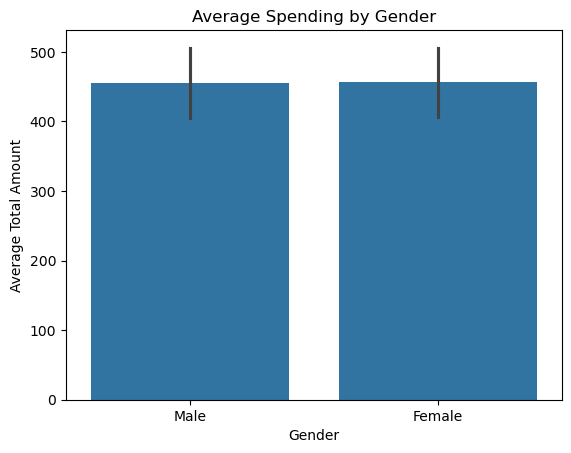

In [5]:
# 1. Analyze the relationship between age, gender, and spending behavior.

sns.barplot(data=df, x='Gender', y='Total Amount')

plt.title("Average Spending by Gender")
plt.ylabel("Average Total Amount")

plt.show()

*Insights :* 
* Male and female average spending is almost the same, indicating gender has little impact.
* The difference between the two groups is minimal, showing similar purchasing behavior.

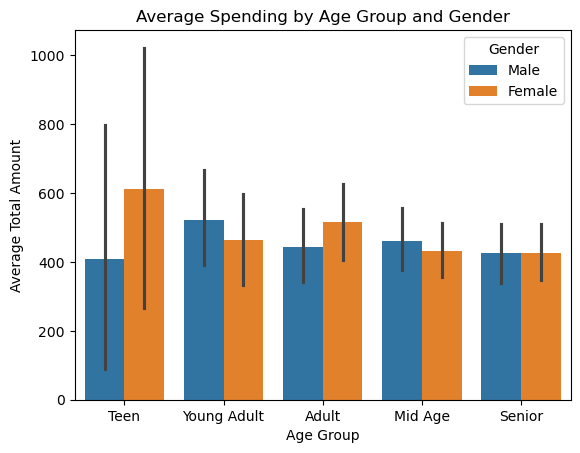

In [51]:
# 2. Compare average spending across different age groups and genders.

# Bar Plot
sns.barplot(data=df, x='Age_Group', y='Total Amount', hue='Gender')

plt.title("Average Spending by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Average Total Amount")
plt.show()

*Insights :*
* Spending is different for different age groups, showing that age affects buying behavior.
* Male and female spending is similar within each group, so gender has little impact.

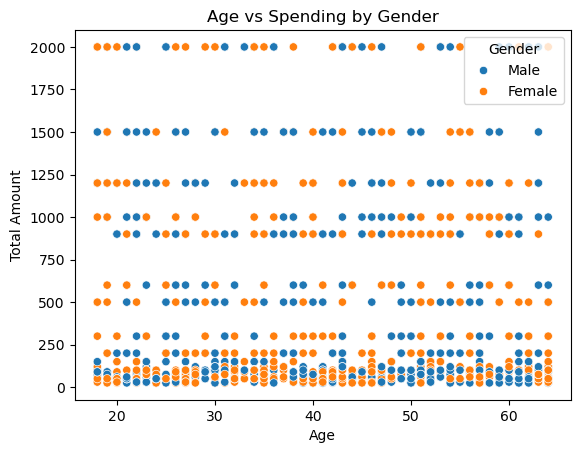

In [97]:
# Scatter Plot
sns.scatterplot(data=df, x='Age', y='Total Amount', hue='Gender')

plt.title("Age vs Spending by Gender")
plt.show()

*Insights :*
* There is no clear relationship between age and spending, and spending varies within each age group.
* Male and female spending patterns are quite similar, with no major difference.

**(B) Sales Patterns Across Time Periods**

- Identify trends in sales over different months, seasons, and years.
- Detect peak and low sales periods.

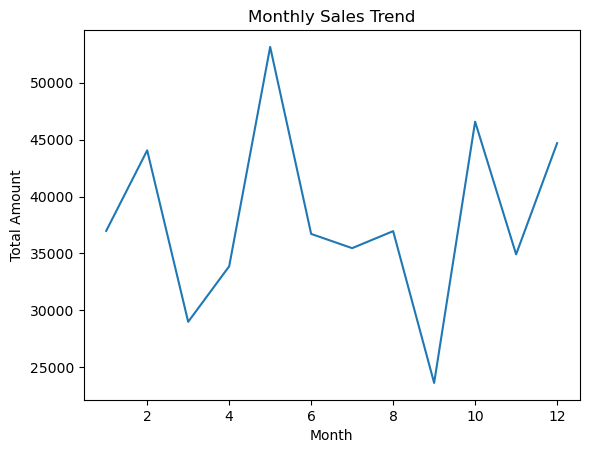

In [65]:
# 1. Identify trends in sales over different months, seasons, and years.

monthly_sales = df.groupby('Month')['Total Amount'].sum().reset_index()

sns.lineplot(x='Month', y='Total Amount', data=monthly_sales)
plt.title("Monthly Sales Trend")
plt.show()

*Insights :*
* Sales change over different months, showing a clear monthly trend
* Some months have higher sales (peaks) and some have lower sales (drops)

In [64]:
# 2. Detect peak and low sales periods

print("Highest Sales Month:")
print(monthly_sales.sort_values(by='Total Amount', ascending=False).head(1).reset_index(drop=True))

print("\nLowest Sales Month:")
print(monthly_sales.sort_values(by='Total Amount').head(1).reset_index(drop=True))

Highest Sales Month:
   Month  Total Amount
0      5         53150

Lowest Sales Month:
   Month  Total Amount
0      9         23620


*Insights :*
* Sales were highest in May (Month 5) with around 53,150.
* Sales were lowest in September (Month 9) with around 23,620.

**(C) Product Category Preferences**

* Determine the most popular product categories by sales volume and revenue.
* Analyze customer demographics for each product category.

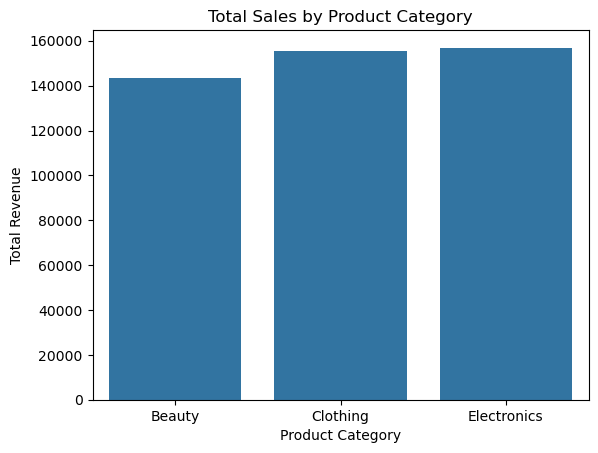

In [89]:
# 1. Determine the most popular product categories by sales volume and revenue.

category_sales = df.groupby('Product Category')['Total Amount'].sum().reset_index()

sns.barplot(x='Product Category', y='Total Amount', data=category_sales)
plt.title("Total Sales by Product Category")
plt.ylabel("Total Revenue")
plt.show()

*Insights :*
* Electronics and Clothing generate slightly higher sales compared to Beauty.
* All categories perform similarly, with no major difference in total sales.

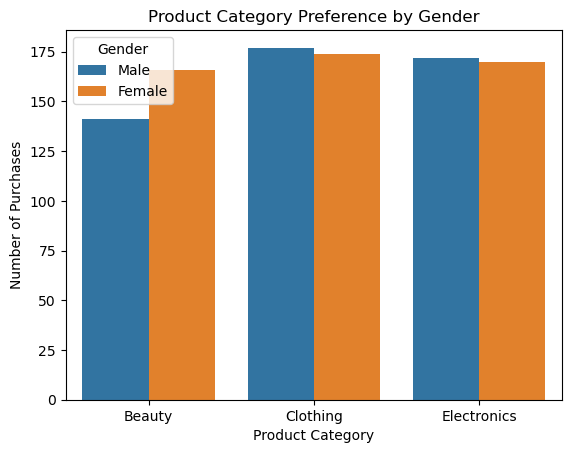

In [90]:
# 2. Analyze customer demographics for each product category.

sns.countplot(x='Product Category', hue='Gender', data=df)

plt.title("Product Category Preference by Gender")
plt.ylabel("Number of Purchases")
plt.show()

*Insights :*
* Both males and females purchase products from all categories in similar numbers.
* There is no major difference in product preference based on gender.

**(D) Customer Spending and Product Preferences**

* Study correlations between age, total spending, and product choices.
* Identify high-value customer segments based on spending behavior.

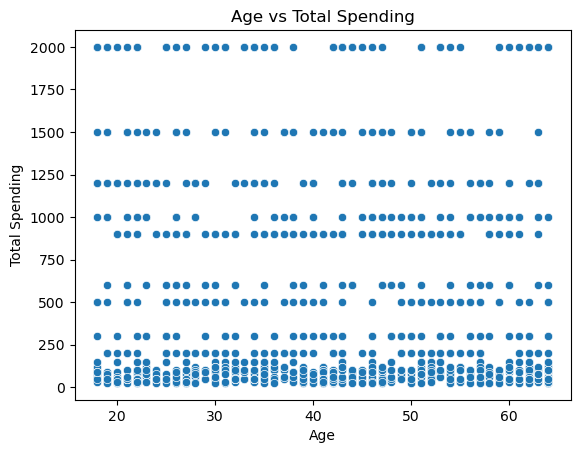

In [92]:
# 1. Study correlations between age, total spending, and product choices.

sns.scatterplot(x='Age', y='Total Amount', data=df)

plt.title("Age vs Total Spending")
plt.xlabel("Age")
plt.ylabel("Total Spending")

plt.show()

*Insights :*
* There is no clear relationship between age and total spending, as the points are scattered.
* People of all age groups show similar spending patterns.

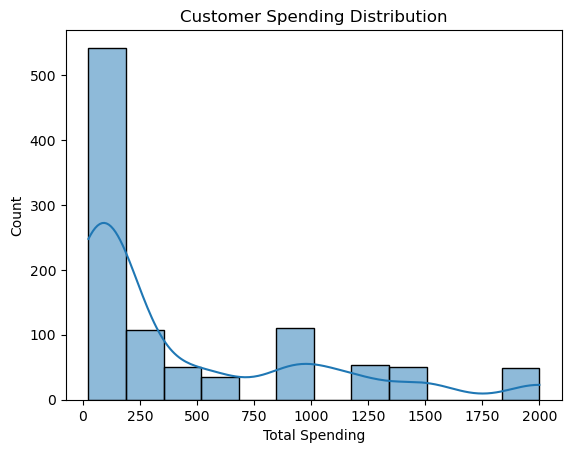

In [95]:
# 2. Identify high-value customer segments based on spending behavior.

sns.histplot(df['Total Amount'], kde=True)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending")
plt.show()

*Insights :*
* Most customers spend a low amount, as the majority of values are on the left side.
* Only a few customers spend very high amounts, indicating high-value customers are fewer.

**(E) Seasonal Shopping Trends**
* Compare purchasing behavior during different seasons. 
* Identify changes in product preferences over time. 

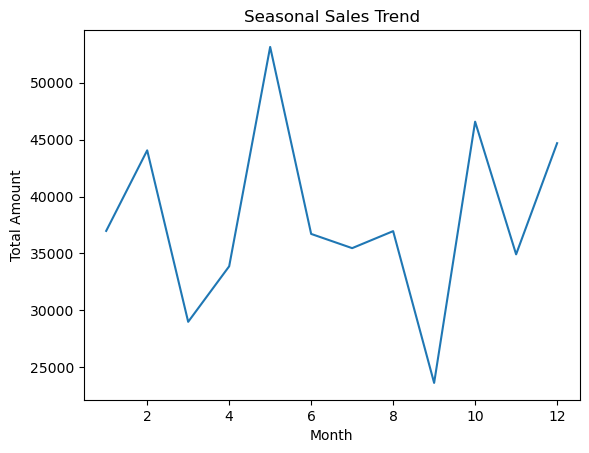

In [67]:
# 1. Compare purchasing behavior during different seasons.

monthly_sales = df.groupby('Month')['Total Amount'].sum().reset_index()

sns.lineplot(x='Month', y='Total Amount', data=monthly_sales)
plt.title("Seasonal Sales Trend")
plt.show()

*Insights :*
* Sales change across different months, showing a clear seasonal pattern.
* Some months have high sales (peaks) and some have low sales (drops).

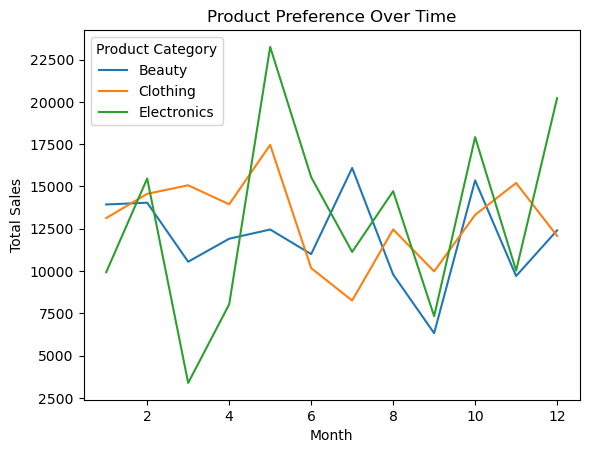

In [72]:
# 2. Identify changes in product preferences over time.

category_trend = df.groupby(['Month','Product Category'])['Total Amount'].sum().reset_index()

sns.lineplot(x='Month', y='Total Amount', hue='Product Category', data=category_trend)
plt.title("Product Preference Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

*Insights :*
* Product preferences change over time, as sales of each category vary across different months.
* Different categories perform better in different months, indicating changing customer demand.

**(F) Transaction-Based Purchasing Behavior** 
* Analyze the impact of quantity bought per transaction on total spending. 
* Identify customer groups that buy in bulk vs. small quantities. 

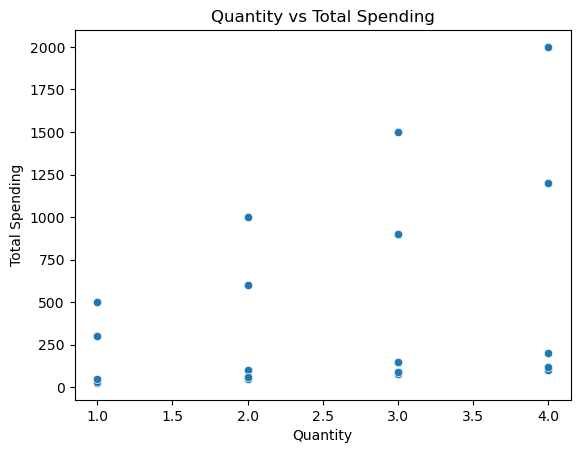

In [76]:
# 1. Analyze the impact of quantity bought per transaction on total spending.

sns.scatterplot(x='Quantity', y='Total Amount', data=df)
plt.title("Quantity vs Total Spending")
plt.ylabel("Total Spending")
plt.show()

*Insights :*
* As quantity increases, total spending also increases, showing a positive relationship.
* Customers who buy in larger quantities tend to spend more overall.

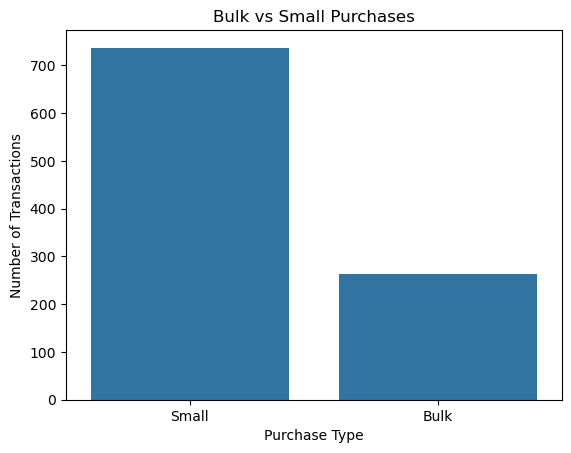

In [78]:
# 2. Identify customer groups that buy in bulk vs. small quantities.

df['Purchase Type'] = df['Quantity'].apply(lambda x: 'Bulk' if x > 3 else 'Small')

# Count of each group
sns.countplot(x='Purchase Type', data=df)
plt.title("Bulk vs Small Purchases")
plt.ylabel("Number of Transactions")
plt.show()

*Insights :*
* Most customers make small quantity purchases, indicating preference for smaller transactions.
* Bulk purchases are fewer, showing that fewer customers buy in large quantities.

**(G) Product Price Distribution Insights**
* Evaluate the price distribution within each product category. 
* Identify price-sensitive and premium product segments. 

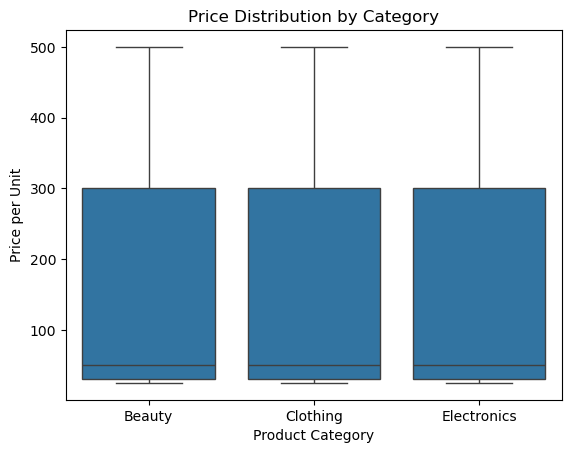

In [83]:
# 1. Evaluate the price distribution within each product category.

sns.boxplot(x='Product Category', y='Price per Unit', data=df)
plt.title("Price Distribution by Category")
plt.show()

*Insights :*
* Prices are spread across a wide range in all categories.
* Most products fall in the lower to mid price range.

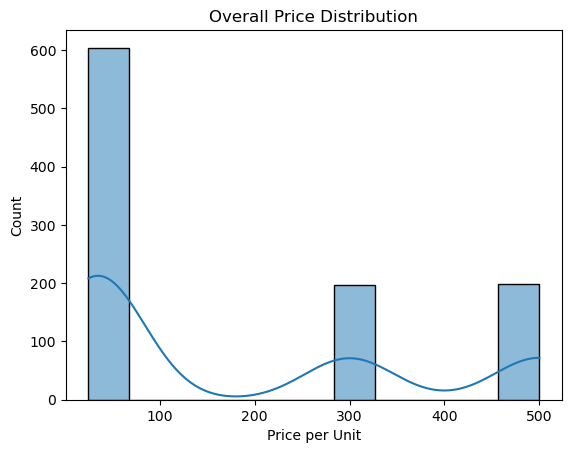

In [82]:
# 2. Identify price-sensitive and premium product segments.

sns.histplot(df['Price per Unit'], kde=True)
plt.title("Overall Price Distribution")
plt.show()

*Insights :*
* Most products are in the lower price range, showing that customers prefer affordable items.
* Fewer products are in the higher price range, indicating limited premium purchases.